In [1]:
# DecodeLabs AI Internship — Project 2: Data Classification Using AI
# Pipeline: Input (load + scale) -> Process (split + KNN) -> Output (confusion matrix + F1)

import numpy as np
import pandas as pd
from sklearn.datasets import load_iris

# Using sklearn's built-in Iris dataset so this notebook runs standalone
# on Kaggle without needing to attach any external dataset.
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)

print(f"Dataset shape: {df.shape}")
print(f"Classes: {list(iris.target_names)}")
print(f"\nClass balance:\n{df['species'].value_counts()}")
print(f"\nFirst few rows:\n{df.head()}")
print(f"\nSummary stats:\n{df.describe()}")

Dataset shape: (150, 5)
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Class balance:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

First few rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

Summary stats:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066  

In [2]:
# Phase 2: Scale -> Split -> Tune K (elbow method) -> Train final model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

X = df[iris.feature_names].values
y = iris.target

# Split BEFORE scaling so the scaler only ever learns from training data —
# fitting it on the full dataset would leak test-set statistics into training.
# shuffle=True removes any ordering bias (Iris is stored sorted by class).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # transform only, never re-fit on test data

# Elbow method: sweep K and track error rate to find the sweet spot between
# overfitting (K too small, memorizes noise) and underfitting (K too large,
# predictions become generic/majority-class).
error_rates = []
k_range = range(1, 21)
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    error_rates.append(1 - knn.score(X_test_scaled, y_test))

best_k = k_range[int(np.argmin(error_rates))]
print(f"Lowest error rate found at K={best_k} (error={min(error_rates):.3f})")

# Train the final model using the best K
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train_scaled, y_train)
predictions = model.predict(X_test_scaled)

print(f"Final model: KNeighborsClassifier(n_neighbors={best_k})")

Lowest error rate found at K=1 (error=0.033)
Final model: KNeighborsClassifier(n_neighbors=1)


Accuracy: 0.967
Weighted F1 Score: 0.967

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



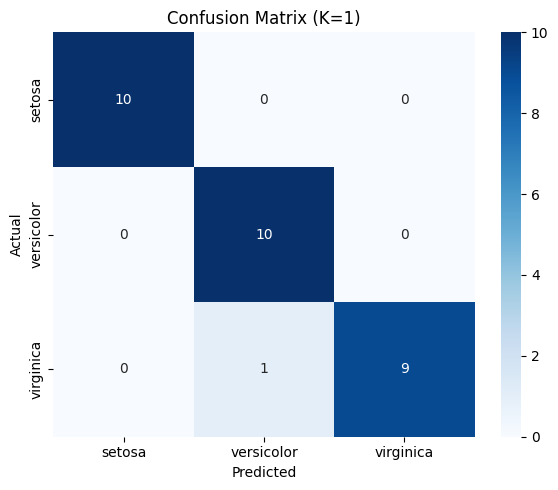


Results saved to /kaggle/working/model_results.txt
Confusion matrix plot saved to /kaggle/working/confusion_matrix.png


In [3]:
# Phase 3: Output Validation — a single accuracy number can hide real
# problems (page 14: "accuracy is a lie" on imbalanced data), so we check
# the confusion matrix and per-class precision/recall/F1 as well.

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

accuracy = accuracy_score(y_test, predictions)
f1 = f1_score(y_test, predictions, average="weighted")
cm = confusion_matrix(y_test, predictions)
report = classification_report(y_test, predictions, target_names=iris.target_names)

print(f"Accuracy: {accuracy:.3f}")
print(f"Weighted F1 Score: {f1:.3f}\n")
print("Classification Report:")
print(report)

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (K={best_k})")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png")
plt.show()

# Save a text summary as the graded deliverable
with open("/kaggle/working/model_results.txt", "w") as f:
    f.write("DecodeLabs Project 2 — Iris Classification Results\n")
    f.write("=" * 50 + "\n")
    f.write(f"Best K (via elbow method): {best_k}\n")
    f.write(f"Accuracy: {accuracy:.3f}\n")
    f.write(f"Weighted F1 Score: {f1:.3f}\n\n")
    f.write("Classification Report:\n")
    f.write(report)
    f.write("\nConfusion Matrix:\n")
    f.write(str(cm))

print("\nResults saved to /kaggle/working/model_results.txt")
print("Confusion matrix plot saved to /kaggle/working/confusion_matrix.png")